<a href="https://colab.research.google.com/github/amairakapoor/covid-xray-classifier/blob/main/covid_xray_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls

sample_data


In [ ]:
!ls

archive.zip  sample_data


In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database
!unzip covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

In [ ]:
import os
import shutil
import random

base_path = "/content/COVID-19_Radiography_Dataset"
target_path = "/content/dataset"

classes = {
    "COVID": "covid",
    "Normal": "normal",
    "Viral Pneumonia": "pneumonia"
}

for key, value in classes.items():
    os.makedirs(f"{target_path}/train/{value}", exist_ok=True)
    os.makedirs(f"{target_path}/test/{value}", exist_ok=True)

    files = os.listdir(f"{base_path}/{key}/images")  # ✅ FIXED
    random.shuffle(files)

    split = int(0.8 * len(files))

    train_files = files[:split]
    test_files = files[split:]

    for f in train_files:
        shutil.copy(f"{base_path}/{key}/images/{f}", f"{target_path}/train/{value}/{f}")

    for f in test_files:
        shutil.copy(f"{base_path}/{key}/images/{f}", f"{target_path}/test/{value}/{f}")

In [ ]:
!ls /content/dataset/train

covid  normal  pneumonia


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 2. LOAD DATA
img_size = 224

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    '/content/dataset/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# 3. BUILD MODEL
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# 4. COMPILE
model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. TRAIN
history = model.fit(train_data, validation_data=test_data, epochs=10)

# 6. FINE-TUNE
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, validation_data=test_data, epochs=5)

# 7. EVALUATE
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

# 8. CONFUSION MATRIX
test_data.reset()

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# 9. SAVE MODEL
model.save("model.keras")

print("Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/train'

In [ ]:
from google.colab import files
files.download("model.keras")

FileNotFoundError: Cannot find file: model.keras

In [1]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 20.8 MB/s eta 0:00:00


Upload your model.h5 file:


Saving model.h5 to model (1).h5
Model loaded successfully!

Upload a chest X-ray image to predict:


Saving COVID-92.png to COVID-92.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


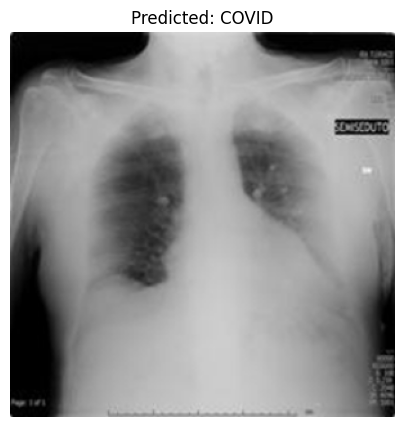


Prediction probabilities:
COVID: 0.996
Normal: 0.004
Pneumonia: 0.000


In [12]:
# COVID X-ray Demo in Colab

# 1️⃣ Install required packages
!pip install tensorflow pillow numpy matplotlib

# 2️⃣ Import libraries
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 3️⃣ Upload your trained model.h5
print("Upload your model.h5 file:")
uploaded = files.upload()
model_file = list(uploaded.keys())[0]

# Load the model
model = load_model(model_file, compile=False)
print("Model loaded successfully!")

# 4️⃣ Upload a chest X-ray image
print("\nUpload a chest X-ray image to predict:")
uploaded_img = files.upload()
img_file = list(uploaded_img.keys())[0]

# Open and preprocess the image
image = Image.open(img_file).convert("RGB")
image_resized = image.resize((224, 224))
img_array = np.array(image_resized) / 255.0  # normalize
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

# 5️⃣ Run prediction
predictions = model.predict(img_array)
class_idx = np.argmax(predictions[0])
class_names = ["COVID", "Normal", "Pneumonia"]

# 6️⃣ Display results
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {class_names[class_idx]}")
plt.show()

print(f"\nPrediction probabilities:")
for i, cls in enumerate(class_names):
    print(f"{cls}: {predictions[0][i]:.3f}")